# Explorar datos a nivel de establecimiento educativo

Objetivos

- Analizar relación entre las variables que caracterizan a los establecimientos
- Identificar casos outliers para revisar pre-procesamiento de los datos

Datos utilizados:

- Puntajes SIMCE matemáticas 2do medio (2024)
- Características de los docentes (2025)
- Indicadores de desarrollo personal y social (2024)

## Cargar librerías y datos


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
path = '/Users/vcanalesg/Documents/diplomado_dcc/0_taller_proyecto/datos'
rbd = pd.read_parquet(path + '/rbd_consolidado.parquet')

## Exploración básica de los datos

- Dimensiones del dataset
- Listado de variables (pendiente)
- Conteo de casos perdidos (pendiente)

In [6]:
print('El dataset tiene ' + str(rbd.shape[0]) + ' establecimientos de educación y ' + str(rbd.shape[1]) + ' variables.')

list(rbd.columns)

El dataset tiene 3000 establecimientos de educación y 147 variables.


['rbd',
 'dvrbd',
 'nom_rbd',
 'cod_reg_rbd',
 'nom_reg_rbd',
 'cod_pro_rbd',
 'nom_pro_rbd',
 'cod_com_rbd',
 'nom_com_rbd',
 'cod_deprov_rbd',
 'nom_deprov_rbd',
 'cod_depe1',
 'cod_depe2',
 'cod_grupo',
 'cod_rural_rbd',
 'nalu_lect2m_rbd',
 'nalu_mate2m_rbd',
 'prom_lect2m_rbd',
 'prom_mate2m_rbd',
 'dif_lect2m_rbd',
 'dif_mate2m_rbd',
 'difgru_lect2m_rbd',
 'difgru_mate2m_rbd',
 'sigdif_lect2m_rbd',
 'sigdif_mate2m_rbd',
 'siggru_lect2m_rbd',
 'siggru_mate2m_rbd',
 'marca_lect2m_rbd',
 'marca_mate2m_rbd',
 'marcadif_lect2m_rbd',
 'marcadif_mate2m_rbd',
 'palu_eda_ins_lect2m_rbd',
 'palu_eda_ele_lect2m_rbd',
 'palu_eda_ade_lect2m_rbd',
 'palu_eda_ins_mate2m_rbd',
 'palu_eda_ele_mate2m_rbd',
 'palu_eda_ade_mate2m_rbd',
 'noaplica',
 'codigo_bbdd',
 'fecha_bbdd',
 'grado',
 'agno',
 'n_matricula_2do_medio',
 'n_misma_comuna_rbd',
 'n_matricula_media',
 'n_matricula_basica',
 'n_mujer',
 'n_mujer_2do_medio',
 'n_mujer_media',
 'n_mujer_basica',
 'n_matricula',
 'p_mujer',
 'p_mujer_2d

## Selección de establecimiento a analizar

No todos los establecimientos tienen puntajes Simce de matemáticas válidos. Esto ocurre por diversos motivos:
- No tienen valor en el promedio del establecimiento (esto podría haberse dado porque el número de estudiantes es muy pequeño).
- El promedio se presenta, pero está marcado como no representativo del desempeño de los estudiantes por factores ajenos a la Agencia.


In [16]:
# marca_mate2m_rbd tiene valor NA cuando el puntaje es válido
# prom_mate2m_rbd corresponde al promedio simce del establecimiento.
rbd_filtrado = rbd[rbd['marca_mate2m_rbd'].isna() | (rbd['prom_mate2m_rbd'].isna() == False)]

# solo establecimientos con GSE bajo

rbd_gse_medio_bajo = rbd_filtrado[rbd_filtrado['cod_grupo'].isin([2,3])]

## Análisis de asociación de variables

Revisar relación entre indicadores de desarrollo personal y social y los puntajes Simce para 2do medio.

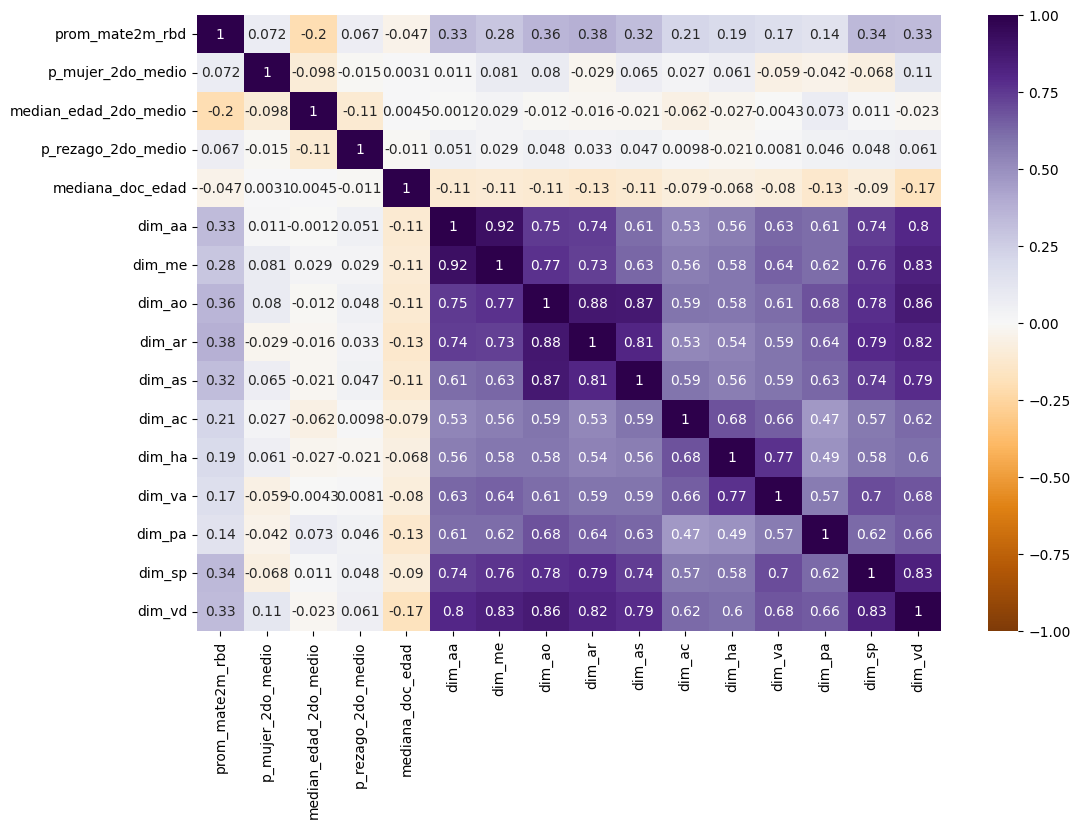

In [19]:
# Variables a considerar:
# prom_mate2m_rbd: promedio simce del establecimiento
# p_mujer_2do_medio: porcentaje de mujeres matriculadas en 2do medio
# median_edad_2do_medio: mediana de edad para matriculados 2do medio
# p_rezago_2do_medio: porcentaje de rezagados
# ind_am: autoestima académica y motivación escolar
# ind_cc: clima de convivencia escolar
# ind_hv: participación y formación ciudadana
# ind_pf: hábitos de vida saludable
# mediana_doc_edad: mediana de edad de los docentes de 2do medio
# n_docentes_rbd: número de docentes
# n_matricula_2do_medio: número de matriculados

variables = ['prom_mate2m_rbd', 'p_mujer_2do_medio', 'median_edad_2do_medio', 'p_rezago_2do_medio','mediana_doc_edad',
             'dim_aa','dim_me', 'dim_ao','dim_ar', 'dim_as','dim_ac', 'dim_ha', 'dim_va', 'dim_pa', 'dim_sp', 'dim_vd']

plt.figure(figsize = (12, 8))

sns.heatmap(rbd_gse_medio_bajo[variables].corr(),
            annot=True,
            vmin=-1, vmax=1,
            cmap='PuOr');


